## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.

**Most of my previous research experience has been in healthcare applications for ML, specifically working with large medical image datasets for prediction and prescription tasks. A big setback of my work at the moment is being able to properly embed images using custom models: latent representations for images can be very weak depending on how they are trained. Something I am interested in is CLIP, where images and text (captions, etc) are aligned in embedding space. This maps on to the concept of alignment in the survey paper, where we wish to use the language modality as the ground truth of the pairing, when training a model to embed the images. Thus, image embeddings should be capturing similar information that the language would. In the case of medicine, this connects succinctly with imaging and radiology reports, which include pathologies and general visual structures as notes.**

2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

**For this, I am basically looking for a image-report pair dataset for medical imaging. There are many multimodal medical datasets (i.e. MIMIC, Biobank, ADNI, etc), but only a couple of these specifically have annotated imaging. The options I found were the following:**

1. **MIMIC-CXR**: chest x-rays with findings/impressions. Very large (over 370,000 image pairs), but exactly what I am looking for.
2. **INSPECT-PE**: pulmonary embolism dataset of scans+notes. Notes seem to be key information extracted from radiology reports, so this might not be good, we want as much detail about the morphologies, pathologies, etc.
3. **CheXpert Plus**: chest x-ray and reports, also applicable, but requires more administrative work to access (accounts, usage restrictions, etc).

In the end, I think the best option is the MIMIC-CXR dataset. Also, in order to minimize the resources needed, I found a good subset on huggingface at https://huggingface.co/datasets/Yamini-1628/MIMIC-CXR-RRG, which is roughly 2,400 image/language pairs, which is much more usable.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

**The two modalities I will be using are images and text. I will be using the CLIP model, or if this does not work, potentially pivoting into report generation for a specific type of imaging. For these datasets, there are no other modalities provided, although there is some metadata that will not be used for training.**

4. What difficulties did you encounter in obtaining the data?

**This dataset is generally accessible and easy to load. The biggest issue is its size, but since I chose a subset of the full MIMIC-CXR dataset, it can be loaded into Colab or even my local machine with ease.**

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?

**The main two challenges that this project addresses will be representation and alignment. Representation, of course, being the unimodal image embeddings that I want to create, and alignment referring to the connection between the ground truth of the radiology reports that I want the image embeddings to approximate. In this way, I believe that CLIP style methods fall into the discrete alignment subchallenge, where we wish to identify the connections between phrases and the morphologies presented. An example of this would be that if we have a tumor in an x-ray, we want the image embedding to encode that tumor's presence in the same way that the phrase "tumor in mid-section" would be encoded in the text's embedding. This could also form into a generation-challenge project, if I were to generate reports. This might fall into the translation subchallenge, as we are essentially translating the imaging into text, by noting important artifacts.**



(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


# Loading in the dataset

In [10]:
from datasets import load_dataset

ds = load_dataset('X-iZhang/MIMIC-CXR-RRG', 'findings_section')
display(ds)

DatasetDict({
    test: Dataset({
        features: ['dicom_id', 'study_id', 'subject_id', 'main_image', 'findings_section', 'impression_section', 'indication_section', 'comparison_section', 'technique_section', 'history_section', 'examination_section', 'prior_image', 'default_prompt', 'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns', 'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning', 'ViewCodeSequence_CodeMeaning', 'PatientOrientationCodeSequence_CodeMeaning', 'view'],
        num_rows: 2461
    })
})

In [32]:
images = ds['test']['main_image']
reports = ds['test']['findings_section']

# EDA

The dataset is comprised of images (main_image), as well as the findings and impressions, and relevant metadata. We also have prior images, indications, comparisons, etc.

In [11]:
# view the dates of images
import pandas as pd

dates = pd.to_datetime(pd.Series(ds['test']['StudyDate']))
dates.describe()

,0
count,2461
mean,2163-04-22 23:45:22.308005888
min,2110-09-12 00:00:00
25%,2142-05-24 00:00:00
50%,2162-04-08 00:00:00
75%,2185-06-12 00:00:00
max,2207-01-29 00:00:00


Here, we see that in order to deidentify patients, the dates have been shifted. Note that as per MIMIC, this shift is randomly chosen for each patient, so relative timing between scans, etc are still correct.

In [12]:
# next, we should check how much missingness we have
metadata_cols = ['dicom_id', 'study_id', 'subject_id', 'ViewPosition', 'Rows',
                 'Columns', 'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning',
                 'ViewCodeSequence_CodeMeaning', 'PatientOrientationCodeSequence_CodeMeaning']

df = ds['test'].select_columns(metadata_cols).to_pandas()
df[metadata_cols].isna().sum()

,0
dicom_id,0
study_id,0
subject_id,0
ViewPosition,0
Rows,0
Columns,0
StudyDate,0
StudyTime,0
ProcedureCodeSequence_CodeMeaning,0
ViewCodeSequence_CodeMeaning,4


The main difficulties in extracting modalities is unstructured nature of notes, as well as the high dimensionality of images. Because images are so large, we cannot easily load these in, and we need to be more exact in how we store them. Also, the images are generally inconsistently sized, so we need to choose a way to standardize them. For notes, each note is unique, which means that in order to do any sort of meaninful visualization of data distributions, we need to preprocess these somehow.

(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**


**For my project, I do not necessarily have labelled data, so these types of visualizations are not as relevant. I've replaced them with other ways to visualize image and text data.**

# Data Distribution

To show the data distribution, we can observe general metadata regarding the size of images, as well as positioning of the device during the scan.

In [50]:
display(df['ViewPosition'].value_counts())

,count
ViewPosition,
AP,1663
PA,798


One consideration is that some x-rays are from the front (PA), and some are from the back (AP). This has some effects on the ways that organs and bones are seen. A potential solution is to use this as a feature to the model, such that the model can adjust according to the view of the x-ray. This would also technically be multimodality in action, as we introduce a tabular feature.

In [51]:
view = df['ViewPosition']

On to size:

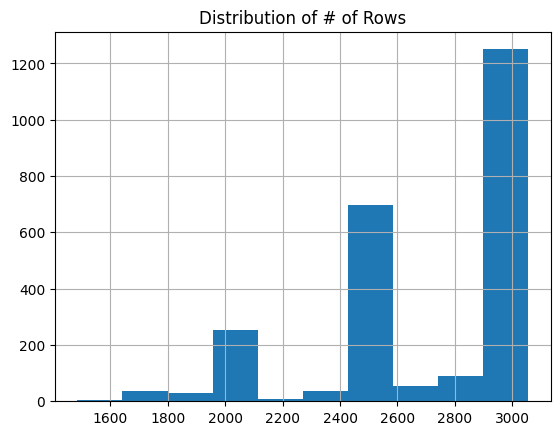

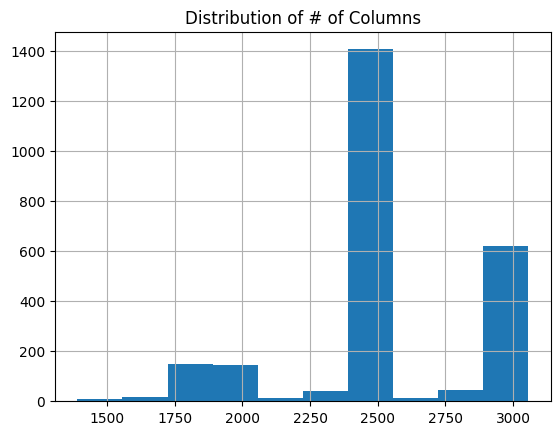

In [52]:
import matplotlib.pyplot as plt

df['Rows'].hist()
plt.title('Distribution of # of Rows')
plt.show()

df['Columns'].hist()
plt.title('Distribution of # of Columns')
plt.show()

To adjust for the multiple sizes used, we need to standardize the shape of the x-ray (in terms of pixels). Instead of doing a crop now, I think the better way to approach this would be to do a randomized crop to the needed size (to be determined) during the training loop, since this will act as data augmentation, helping our model to generalize.

# Samples

To visualize samples, I will just show multiple pairs of x-rays and the associated findings, so that we can manually verify the connections.

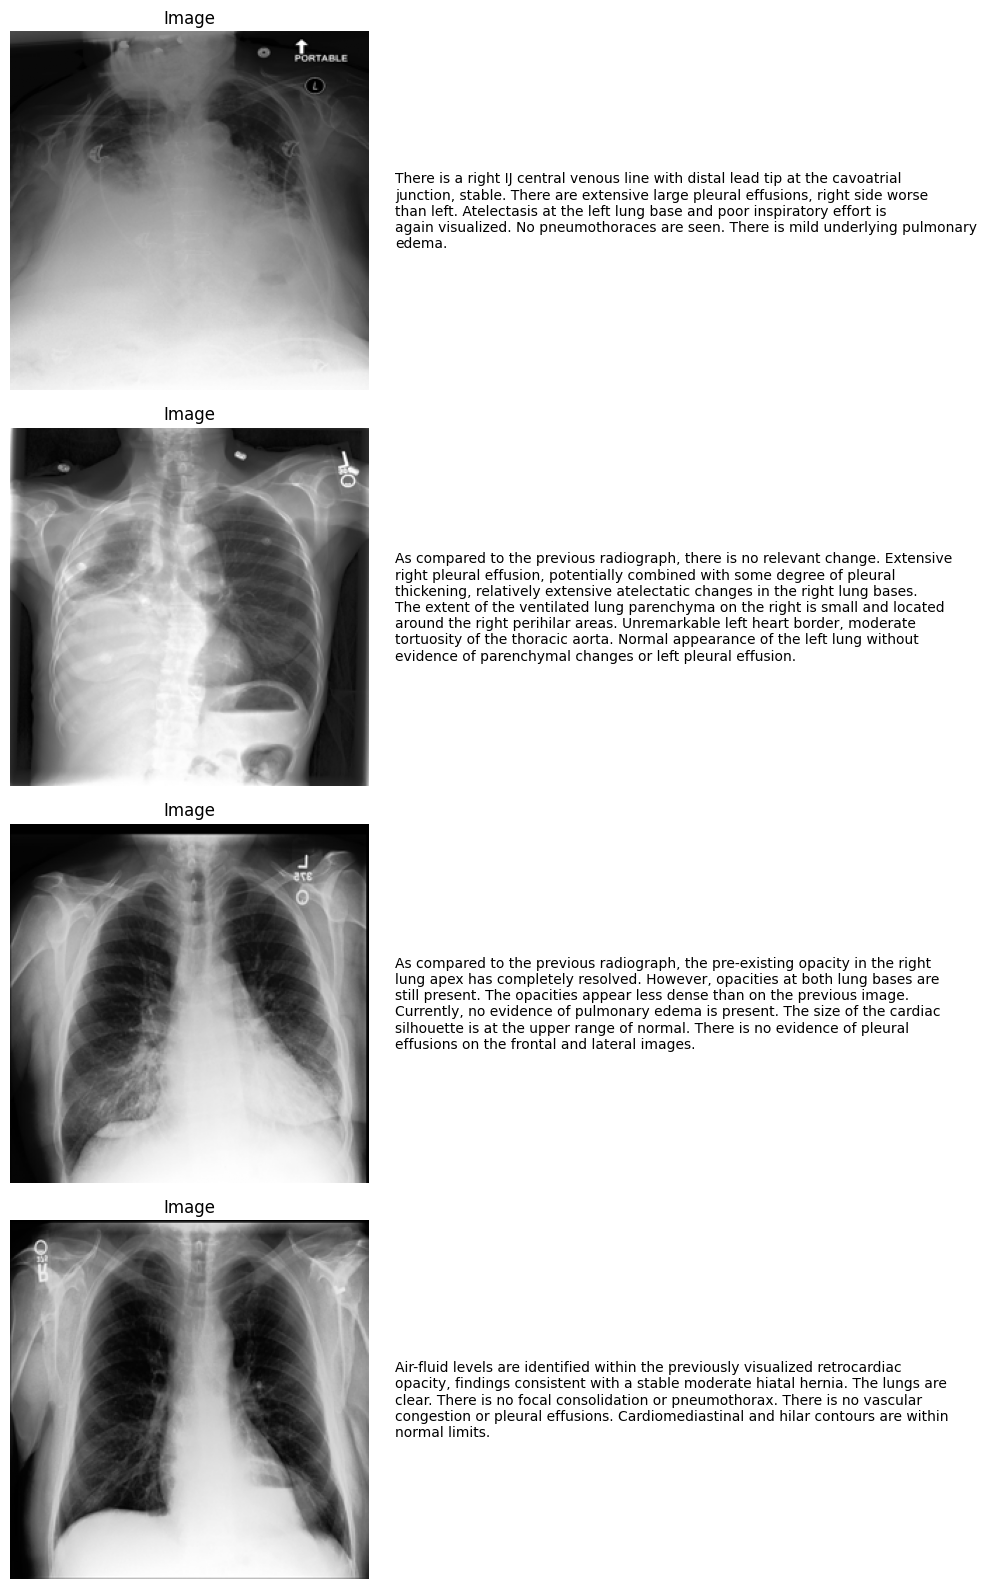

In [67]:
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import textwrap

def visualize_samples(images, reports, num_samples=5):
    """
    Visualize random image-report pairs side by side.

    Args:
        images (list of PIL.Image): List of PIL images
        reports (list of str): Corresponding text reports
        num_samples (int): Number of samples to visualize
    """
    indices = random.sample(range(len(images)), num_samples)
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))

    for i, idx in enumerate(indices):
        img = images[idx]
        report = reports[idx]
        img = img.resize((256, 256)) # resize to fit into grid
        img = np.array(img)

        ax_img = axes[i, 0]
        if img.ndim == 2:  # grayscale
            ax_img.imshow(img, cmap='gray')
        elif img.ndim == 3 and img.shape[2] == 1:
            ax_img.imshow(img.squeeze(-1), cmap='gray')
        else:
            ax_img.imshow(img)
        ax_img.axis('off')
        ax_img.set_title("Image", fontsize=12)

        ax_txt = axes[i, 1]
        ax_txt.axis('off')
        wrapped_text = "\n".join(textwrap.wrap(report, width=80)) # wrap the text at 80 characters
        ax_txt.text(0, 0.5, wrapped_text, fontsize=10, va='center', ha='left')

    plt.tight_layout()
    plt.show()


visualize_samples(images, reports, 4)

# Input Distribution

In terms of the inputs to the model, there will be two: images and embedded text. Assuming the embedded text will capture the same information as the raw text, we can observe some of the distribution of text length, keywords, etc.

For images, we can generally observe pixel intensities and their distributions.



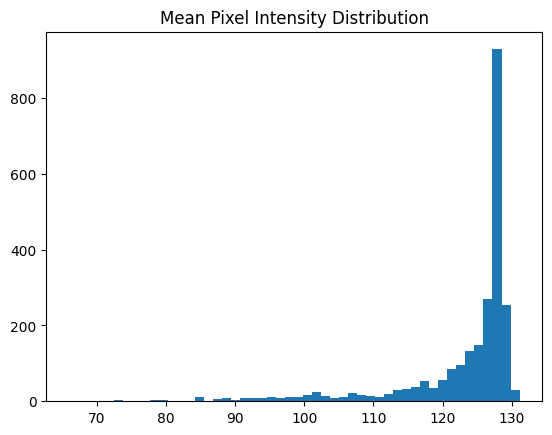

In [69]:
pixel_means = [np.array(img).mean() for img in images]
plt.hist(pixel_means, bins=50)
plt.title("Mean Pixel Intensity Distribution")
plt.show()

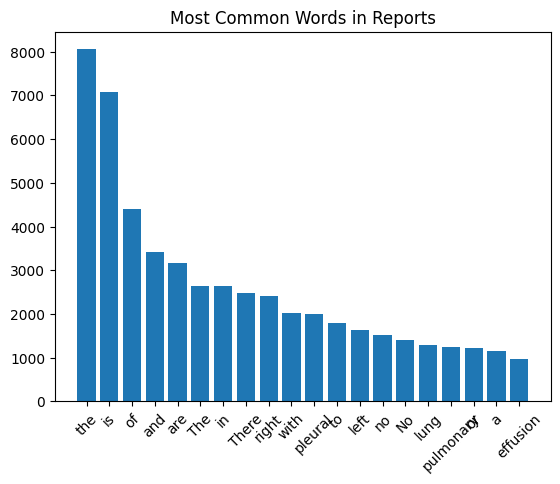

In [74]:
from collections import Counter

all_words = ' '.join([r for r in reports]).split()
c = Counter(all_words)

most_common = c.most_common(20)

words, counts = zip(*most_common)
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Common Words in Reports")
plt.show()

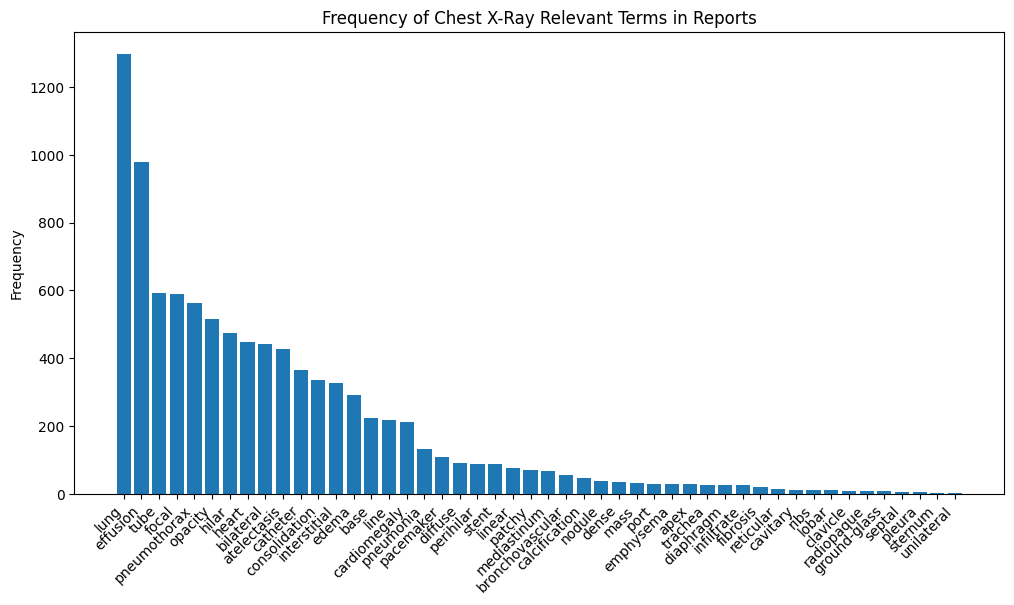

In [76]:
# obviously, the above is not very helpful, so I'll focus on medical terms that are relevant:

# ChatGPT wrote me a list of terms that are medically relevant to chest x-rays
chest_xray_terms = [
    # Anatomy / Structures
    "lung", "heart", "mediastinum", "pleura", "trachea",
    "bronchus", "hilar", "diaphragm", "apex", "base",
    "ribs", "clavicle", "sternum", "pulmonary artery", "bronchovascular",

    # Pathology / Findings
    "infiltrate", "consolidation", "opacity", "effusion", "pneumothorax",
    "edema", "atelectasis", "nodule", "mass", "calcification",
    "fibrosis", "emphysema", "pneumonia", "cardiomegaly", "pleural thickening",

    # Imaging descriptors
    "bilateral", "unilateral", "diffuse", "focal", "patchy",
    "reticular", "ground-glass", "interstitial", "perihilar", "lobar",
    "cavitary", "septal", "linear", "dense", "radiopaque",

    # Procedures / Devices
    "catheter", "line", "tube", "pacemaker", "endotracheal tube",
    "port", "stent", "chest tube", "ventilator", "surgical clips"
]

chest_xray_terms_lower = [t.lower() for t in chest_xray_terms]
filtered_counts = {word: count for word, count in c.items() if word in chest_xray_terms_lower}

filtered_counts = dict(sorted(filtered_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12,6))
plt.bar(filtered_counts.keys(), filtered_counts.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.title("Frequency of Chest X-Ray Relevant Terms in Reports")
plt.show()

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

**For CLIP methods, evaluation is slightly different, since this is technically a unsupervised or self-supervised learning problem. Instead, I have given the loss, called InfoNCE, that is used to train the model.**

In [77]:
import torch
import torch.nn.functional as F

def clip_contrastive_loss(image_embeds, text_embeds, temperature=0.07):
    image_embeds = F.normalize(image_embeds, dim=1)
    text_embeds = F.normalize(text_embeds, dim=1)

    logits = torch.matmul(image_embeds, text_embeds.T) / temperature
    labels = torch.arange(logits.size(0)).to(logits.device)

    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i) / 2

**We could also do some basic evaluation using retrieval metrics, such as top-1, top-5 accuracy, or mean rank, where for each image, we rank all texts by embedding similarity, then observe how similar the image is to the correct text. Here is an implementation of the mean rank:**

In [78]:
def mean_rank(image_embeds, text_embeds):
    """
    Computes the mean rank of the correct matches for image->text and text->image
    """
    image_embeds = F.normalize(image_embeds, dim=1)
    text_embeds = F.normalize(text_embeds, dim=1)

    sims = torch.matmul(image_embeds, text_embeds.T)  # cosine similarities
    batch_size = sims.size(0)

    ranks_i2t = torch.argsort(torch.argsort(-sims, dim=1), dim=1)  # double argsort gives ranks
    correct_ranks_i2t = ranks_i2t[torch.arange(batch_size), torch.arange(batch_size)].float() + 1  # 1-based
    ranks_t2i = torch.argsort(torch.argsort(-sims.T, dim=1), dim=1)
    correct_ranks_t2i = ranks_t2i[torch.arange(batch_size), torch.arange(batch_size)].float() + 1

    return ((correct_ranks_i2t.mean() + correct_ranks_t2i.mean()) / 2).item()

Furthermore, we can also use the embeddings of downstream classification tasks, which would use metrics such as accuracy or AUC.

(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

**Read the following review. Using only one word, output the sentiment of the review as either positive, negative, or neutral.**

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

**Observe the face in the image, and using only one word, output the emotion that the person is expressing, as either angry, sad, or happy.**

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

**Read the following paragraph and answer three questions, subsequently: 1. What is the name of the main person mentioned (the subject)? 2. Where is this person going? 3. What activity is the person planning to do? Write exactly one sentence for each question.**

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

**I think the most interesting topics were those discussed in the survey paper. The methodical distinctions between different use cases for multimodal learning seems very underexplored, and this is my first real introduction to concepts such as alignment or transference.**

**The most challenging aspect has been finding the dataset. I assumed that there would be plenty of Kaggle datasets ready for use, but this was not the case for my project idea that I had in mind. I think partly because I was looking for medical data, which can often be observational data, and therefore HIPAA protected, and also because imaging modalities are resource constrained. I addressed this by using public medical datasets, and by finding a subset that would fit my local machine.**

**I think because of the rigor of the notes, and the generally standard nature of the x-rays, I am very happy about the quality of my dataset. I am not an expert in CLIP, so I have little understanding on whether this sized dataset is sufficient, but I can scale if needed. In terms of lacking, the only possible thing that I can think of is whether the notes do not capture enough about benign morphology: it might make sense to also have the embeddings capture normal x-ray features. This will be something to consider or fix later on in the process, once I have started my modelling.**